In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot
import statsmodels.api as sm

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor



import optuna
from optuna.visualization import plot_slice

In [3]:
qualitative = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
              'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
              'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
              'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
              'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
              'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
              'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish', 
              'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
              'SaleType', 'SaleCondition', 'MoSold']

quantitative = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',  
               'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 
               'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 
               'PoolArea', 'MiscVal']

date = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt']

target = np.log1p(train_raw['SalePrice'])

# Pipeline de prétraitement

La pemière étape consiste à créer un pipeline de prétraitement des données. Plus haut, nous avons prétraité les données manuellement pour le Baseline, mais ici nous allons le faire manuellement uniquement pour les dates. Pour les variables quantitatives et qualitatives, nous allons utiliser des transformers de la librarie scikit-learn. Mis bout à bout, ces transformers vont créer notre pipeline de prétraitement. Ce dernier sera réutilisable avec tous les modèles que nous allons tester par la suite.

In [4]:
# ----------------------
# 1. Charger les données brutes
# ----------------------

train_raw = pd.read_csv('Data/train.csv', index_col='Id')      # train.csv avec target SalePrice
test_raw = pd.read_csv('Data/test.csv', index_col='Id')        # test.csv sans SalePrice
data_raw = pd.concat([train_raw.drop(columns='SalePrice').copy(), test_raw.copy()])  # concat pour traitement centralisé

# ----------------------
# 2. Fonction de transformation des dates en durées
# ----------------------

def compute_relative_dates(df):
    df = df.copy()
    df['YearsSinceBuilt'] = df['YrSold'] - df['YearBuilt']
    df['YearsSinceRemod'] = df['YrSold'] - df['YearRemodAdd']
    df['YearsSinceGarage'] = df['YrSold'] - df['GarageYrBlt'].fillna(df['YearBuilt'])
    return df[['YearsSinceBuilt', 'YearsSinceRemod', 'YearsSinceGarage']]


# Transformer scikit-learn compatible avec la nouvelle fonction date
date_transformer = Pipeline(steps=[
    ('relativedates', FunctionTransformer(compute_relative_dates, validate=False))
])

# ----------------------
# 3. Pipeline pour les colonnes numériques
# ----------------------

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),     # remplace les NaN par la moyenne
    ('scaler', StandardScaler())                     # normalise (utile pour modèles linéaires, SVM…)
])

# ----------------------
# 4. Pipeline pour les colonnes catégorielles
# ----------------------

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),  # ajoute une vraie catégorie "Missing"
    ('encoder', OneHotEncoder(handle_unknown='ignore'))                     # transforme en colonnes binaires, ignore les inconnues au test
])

# ----------------------
# 5. Assemblage global via ColumnTransformer
# ----------------------

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, quantitative),       # traitement des numériques
    ('cat', categorical_transformer, qualitative), # traitement des catégorielles
    ('dates', date_transformer, date)              # traitement des dates
], remainder='drop')  

# ----------------------
# 6. Préparation des données
# ----------------------
X_train = data_raw.loc[train_raw.index]
X_test = data_raw.loc[test_raw.index]
y_train = target.copy()

# ----------------------
# 7. Exemple d’utilisation (sans modèle)
# ----------------------

# Création du pipeline de prétrainement
preprocessing_pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

# Transformation des données d'entraînement et affichage du nombre de features après prétrainement
X_processed = preprocessing_pipeline.fit_transform(X_train)
nb_features = X_processed.shape[1]

print(f"Nombre de features après preprocessing : {nb_features}")

# Affichage du pipeline de prétrainement
preprocessing_pipeline


Nombre de features après preprocessing : 365


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LotFrontage', 'LotArea',
                                                   'OverallQual', 'OverallCond',
                                                   'MasVnrArea', 'BsmtFinSF1',
                                                   'BsmtFinSF2', 'BsmtUnfSF',
                                                   'TotalBsmtSF', '1stFlrSF',
                                                   '2ndFlrSF', 'LowQualFinSF',
                                                   'GrLivArea', 'GarageArea',
                                                   'WoodDeckSF', 'OpenPorchSF...
                                                   'Exterior1st', 'Exterior2nd',
                                                   'MasVnrType', 'ExterQual',
                                                   'ExterCond', 'Foundation',
                                                   'BsmtQual', 'BsmtCond',
                                                   'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir', ...]),
                                                 ('dates',
                                                  Pipeline(steps=[('relativedates',
                                                                   FunctionTransformer(func=<function compute_relative_dates at 0x00000222B0256660>))]),
                                                  ['YearBuilt', 'YearRemodAdd',
                                                   'YrSold',
                                                   'GarageYrBlt'])]))])

# Modèle 1 - Random Forest (Brian)

In [5]:
# ----------------------
# Méthode pour optimiser le modèle RandomForest
# ----------------------
def random_forest_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 40),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return -scores.mean()

Pour ce modèle `Random Forest Regressor`, différents tests ont été réalisés afin de sélectioner les meilleures plages d'hyperparamètres. Voici une justification pour chaque paramètre :
 - **n_estimators** : plus le nombre d'arbres est élevé, plus le modèle est stable. Cependant, ils ont été limités à 1000 afin d'éviter un temps d'entrainement trop conséquent.
 - **max_depth** : Une bonne profondeur est indispensable pour éviter l'overfitting et l'underfitting. Une taille trop petite est trop restrictive et au dela de 40 est peu utile pour un data set moyen comme celui-ci (environ 1400 lignes)
 - **min_samples_split** : En augmentant cette valeur, il est possible d'éviter l'overfitting. L'objectif est donc de laisser une certaine liberté au modèle, afin qu'il puisse avoir des splits profonds (2) ou plus restreints (20).
 - **min_samples_leaf** : Pour cet hyperparamètre, une certaine liberté est donnée également. Le fait d'avoir une valeur petite (1) peut rendre le modèle sensible au bruit, il faut donc avoir une valeur maximale (10) cohérente pour forcer des règles plus générales.
 - **max_features** : Cette valeur permet de réduire le nombre de features candidates pour chaque noeud, le but est donc de donner trois façons de faire plus ou moins restrictives pour permettre de tester des cas différents.

# Modèle 2 - Régression Lasso (Brian)

In [6]:
# ----------------------
# Méthode pour optimiser le modèle Lasso
# ----------------------
def lasso_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    alpha = trial.suggest_float('alpha', 1e-4, 10.0, log=True)
    model = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return -scores.mean()

Pour modèle, le seul hyperparamètres intéressant est l'alpha. Ce dernier contrôle la force de la régularisation L1 appliquée. Un alpha faible donne un modèle très flexible, qui risque de surajuster. Alors qu'un grand alpha offre une régularisation forte et donc un modèle très rigide (car de nombreux coefficients seront faibles). Comme nous avons un data set moyen avec beaucoup de features (365), un risque de surajustement existe. Ici la borne supérieure (10) nous permet de ne pas avoir un modèle trop rigide et sous-ajusté. 

Nous sommes conscients que certains modèles (comme Lasso ou Ridge) peuvent présenter un `second sweet spot` pour des valeurs extrêmes d’hyperparamètres, mais cette hypothèse ne sera pas explorée dans le cadre de ce projet.

# Modèle 3 - Decision Tree (Marino)

In [17]:
# ----------------------
# Méthode pour optimiser le modèle DecisionTree
# ----------------------
def decision_tree_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    
    params = {
        'max_depth': trial.suggest_int('max_depth', 10, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 15),
        'max_features': trial.suggest_categorical('max_features', [None,'sqrt'] )
    }

    model = DecisionTreeRegressor(**params, random_state=42)

    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    return -scores.mean()

# Modèle 4 - XGBoost (Marino)

In [21]:
# ----------------------
# Méthode pour optimiser le modèle XGBoost
# ----------------------
def xgboost_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    params = {
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 500, 1200),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.3),
        'alpha': trial.suggest_float('alpha', 1e-6, 100, log=True),
        'lambda': trial.suggest_float('lambda', 1e-6, 100, log=True)
    }

    model = XGBRegressor(**params, objective='reg:squarederror', random_state=42, n_jobs=-1)

    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    return -scores.mean()

# Evaluation des modèles

In [22]:
def evaluate_and_optimize_models(model_configs, X, y, preprocessing_pipeline, cv=5, n_trials=30, scoring='neg_root_mean_squared_error'):
    """
    Optimise les modèles avec Optuna puis évalue leur performance via validation croisée.

    Paramètres:
    - model_configs: dict[str, callable], nom du modèle -> fonction objective(trial, pipeline, X, y)
    - X, y: données d'entrée brutes (non transformées)
    - preprocessing_pipeline: pipeline de prétraitement à injecter dans chaque modèle
    - cv: nombre de folds pour la cross-validation
    - n_trials: nombre d’essais pour Optuna
    - scoring: métrique (RMSE négatif par défaut)

    Retourne : dict avec les résultats RMSE moyens + std
    """

    results = {}

    for name, objective_func in model_configs.items():
        print(f"\nOptimisation pour : {name}")

        def wrapped_objective(trial):
            return objective_func(trial, preprocessing_pipeline, X, y, cv, scoring)

        study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42), study_name=name)
        study.optimize(wrapped_objective, n_trials=n_trials, show_progress_bar=True)

        best_score = study.best_value
        best_params = study.best_params
        print(f"✅ {name} | RMSE = {best_score:.4f} | Paramètres: {best_params}")
        print("------------------------------------")

        results[name] = (best_score, best_params, study)
    
    # Affichage graphique
    names = list(results.keys())
    means = [results[name][0] for name in names]

    plt.figure(figsize=(10, 5))
    plt.bar(names, means)
    plt.ylabel("Meilleur RMSE (CV)")
    plt.title("Comparaison des modèles optimisés")
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    return results

[I 2025-05-31 18:09:24,928] A new study created in memory with name: Lasso



Optimisation pour : Lasso


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2025-05-31 18:09:25,101] Trial 0 finished with value: 0.15685709582574453 and parameters: {'alpha': 0.0074593432857265485}. Best is trial 0 with value: 0.15685709582574453.
[I 2025-05-31 18:09:25,240] Trial 1 finished with value: 0.3736406159221102 and parameters: {'alpha': 5.669849511478847}. Best is trial 0 with value: 0.15685709582574453.


[I 2025-05-31 18:09:25,372] A new study created in memory with name: Random Forest


...

[I 2025-05-31 18:09:39,324] Trial 0 finished with value: 0.18753359703680367 and parameters: {'max_depth': 17, 'min_samples_split': 20, 'min_samples_leaf': 14, 'max_features': None}. Best is trial 0 with value: 0.18753359703680367.
[I 2025-05-31 18:09:39,491] Trial 1 finished with value: 0.22455167927387037 and parameters: {'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 15, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.18753359703680367.


[I 2025-05-31 18:09:39,674] A new study created in memory with name: XGBoost


[I 2025-05-31 18:09:39,670] Trial 2 finished with value: 0.18757090449527075 and parameters: {'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 14, 'max_features': None}. Best is trial 0 with value: 0.18753359703680367.
✅ Decision Tree | RMSE = 0.1875 | Paramètres: {'max_depth': 17, 'min_samples_split': 20, 'min_samples_leaf': 14, 'max_features': None}
------------------------------------

Optimisation pour : XGBoost


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2025-05-31 18:09:40,432] Trial 0 finished with value: 0.1576764326604003 and parameters: {'eta': 0.11861663446573512, 'n_estimators': 1166, 'max_depth': 16, 'min_child_weight': 8, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.017425083650459836, 'alpha': 8.499808989183016, 'lambda': 0.06440507553993717}. Best is trial 0 with value: 0.1576764326604003.
[I 2025-05-31 18:09:40,962] Trial 1 finished with value: 0.13562294942241618 and parameters: {'eta': 0.21534104756085318, 'n_estimators': 514, 'max_depth': 20, 'min_child_weight': 9, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'gamma': 0.055021352956030146, 'alpha': 0.000271605114465485, 'lambda': 0.01577798188336503}. Best is trial 1 with value: 0.13562294942241618.
[I 2025-05-31 18:09:41,503] Trial 2 finished with value: 0.1405693361360239 and parameters: {'eta': 0.13526405540621358, 'n_estimators': 704, 'max_depth': 14, 'min_child_weight': 5, 'subsample': 0.646072324

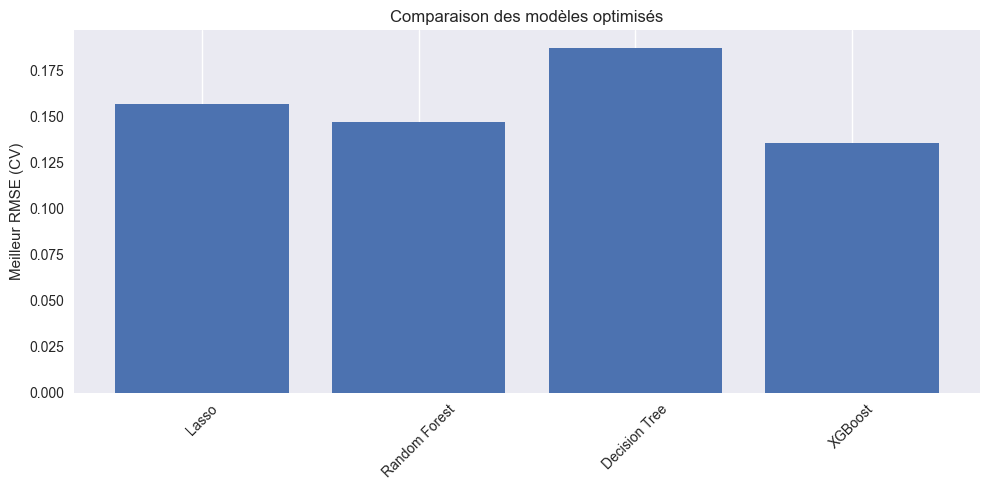

In [23]:
model_configs = {
    'Lasso': lasso_objective,
    'Random Forest': random_forest_objective,
    'Decision Tree': decision_tree_objective,
    'XGBoost': xgboost_objective
}

results = evaluate_and_optimize_models(model_configs, X_train, y_train, preprocessing_pipeline, n_trials=3)

lasso_best_params = results['Lasso'][1]
random_forest_best_params = results['Random Forest'][1]
decision_tree_best_params = results['Decision Tree'][1]
xgboost_best_params = results['XGBoost'][1]

## Modèle Stacking Regressor

In [25]:
def stacking_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    lasso_pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', Lasso(lasso_best_params['alpha'], max_iter=10000, random_state=42))
    ])

    random_forest_pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', RandomForestRegressor(
            n_estimators=random_forest_best_params['n_estimators'],
            max_depth=random_forest_best_params['max_depth'],
            min_samples_split=random_forest_best_params['min_samples_split'],
            min_samples_leaf=random_forest_best_params['min_samples_leaf'],
            max_features= random_forest_best_params['max_features'],
            random_state=42,
            n_jobs=-1
        ))

    ])

    decision_tree_pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', DecisionTreeRegressor(
            max_depth=decision_tree_best_params['max_depth'],
            min_samples_split=decision_tree_best_params['min_samples_split'],
            min_samples_leaf=decision_tree_best_params['min_samples_leaf'],
            max_features=decision_tree_best_params['max_features'],
            random_state=42
        ))
    ])

    xgboost_pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', XGBRegressor(
            eta=xgboost_best_params['eta'],
            n_estimators=xgboost_best_params['n_estimators'],
            max_depth=xgboost_best_params['max_depth'],
            min_child_weight=xgboost_best_params['min_child_weight'],
            subsample=xgboost_best_params['subsample'],
            colsample_bytree=xgboost_best_params['colsample_bytree'],
            gamma=xgboost_best_params['gamma'],
            alpha=xgboost_best_params['alpha'],
            lambda_=xgboost_best_params['lambda'],
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1
        ))
    ])

    # Modifier les paramètres du Ridge ? (Alpha)
    final_estimator = Ridge(alpha=trial.suggest_float('ridge_alpha', 0.01, 10.0, log=True))

    stacking = StackingRegressor(
        estimators=[
            ('lasso', lasso_pipeline),
            ('random_forest', random_forest_pipeline),
            ('decision_tree', decision_tree_pipeline),
            ('xgboost', xgboost_pipeline)
        ],
        final_estimator=final_estimator,
        cv=cv,
        n_jobs=-1
    )

    scores = cross_val_score(stacking, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return -scores.mean()

[I 2025-05-31 18:11:33,266] A new study created in memory with name: Stacking



Optimisation pour : Stacking


  0%|          | 0/2 [00:00<?, ?it/s]

[I 2025-05-31 18:12:34,716] Trial 0 finished with value: 0.1345112932007242 and parameters: {'ridge_alpha': 0.13292918943162169}. Best is trial 0 with value: 0.1345112932007242.
[I 2025-05-31 18:13:35,104] Trial 1 finished with value: 0.13347997439551568 and parameters: {'ridge_alpha': 7.114476009343421}. Best is trial 1 with value: 0.13347997439551568.
✅ Stacking | RMSE = 0.1335 | Paramètres: {'ridge_alpha': 7.114476009343421}
------------------------------------


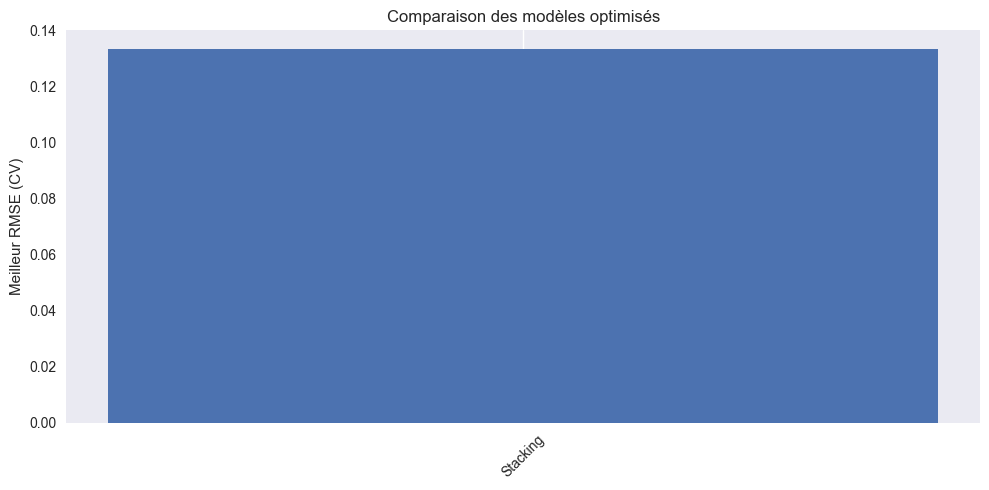

In [26]:
model_configs = {
    'Stacking': stacking_objective
}
results = evaluate_and_optimize_models(model_configs, X_train, y_train, preprocessing_pipeline, n_trials=2)